# Visualizing Gradient Boosting Hyperparameter Tuning
This notebook trains a Gradient Boosting Regressor model and visualizes the hyperparameter tuning process. We will compare its performance to the previous Elastic-Net linear model.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

## 1. Load and Prepare the Data
We use the same data preparation steps as before to ensure a fair comparison.

In [2]:
file_path = 'california_housing.csv'
housing_df = pd.read_csv(file_path)

X = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Hyperparameter Tuning with GridSearchCV
We will tune several key hyperparameters for the `GradientBoostingRegressor`:
- `n_estimators`: The number of boosting stages (trees) to perform.
- `learning_rate`: Shrinks the contribution of each tree.
- `max_depth`: The maximum depth of the individual regression estimators.

In [3]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gbr', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'gbr__n_estimators': [100, 200],
    'gbr__learning_rate': [0.05, 0.1],
    'gbr__max_depth': [3, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, 
                           scoring='neg_mean_squared_error', 
                           verbose=2, n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gbr__learning_rate': [0.05, 0.1], 'gbr__max_depth': [3, 5], 'gbr__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [4]:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score (negative MSE): ", grid_search.best_score_)

Best parameters found:  {'gbr__learning_rate': 0.1, 'gbr__max_depth': 5, 'gbr__n_estimators': 200}
Best cross-validation score (negative MSE):  -0.2254136418475639


## 3. Visualizing the Grid Search Results
Visualizing a 3D grid search is more complex. We will create a pivot table and a heatmap to show the impact of the two most important hyperparameters: `n_estimators` and `learning_rate`, while holding `max_depth` constant at the best-found value.

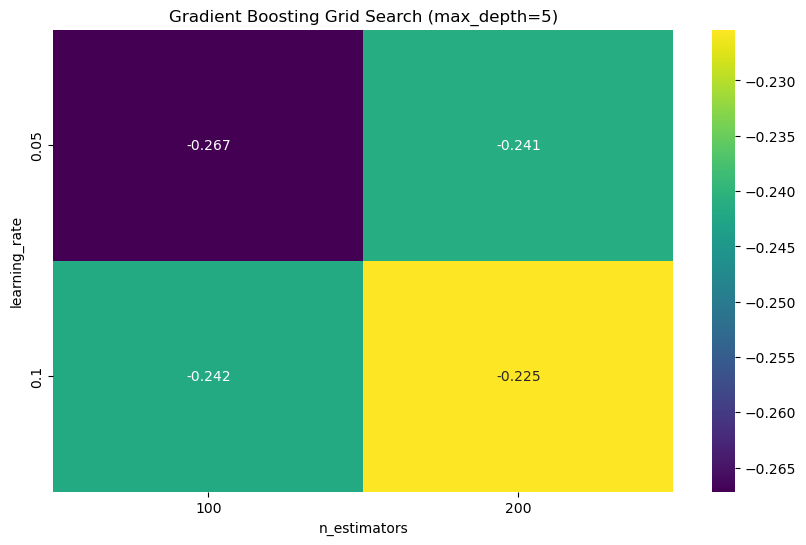

In [5]:
results = pd.DataFrame(grid_search.cv_results_)
best_max_depth = grid_search.best_params_['gbr__max_depth']
filtered_results = results[results['param_gbr__max_depth'] == best_max_depth]

pivot = filtered_results.pivot_table(index='param_gbr__learning_rate', 
                                     columns='param_gbr__n_estimators', 
                                     values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis')
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.title(f'Gradient Boosting Grid Search (max_depth={best_max_depth})')
plt.show()

## 4. Final Evaluation on the Test Set
Finally, we evaluate the best Gradient Boosting model on the test set.

In [6]:
y_pred = grid_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error on test set: {rmse}")

Root Mean Squared Error on test set: 0.47367594185279
